In [6]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


if Path.cwd().name in {"notebooks", "research"}:
    os.chdir(Path.cwd().parent)

from src.data.data_manager import DataManager
from src.analytics.factor_model import FactorEngine

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")
print(f"Data path exists: {(Path.cwd() / 'data' / 'raw').exists()}")

CWD: c:\Users\reymo\quant-portfolio
Data path exists: True


In [7]:
from src.analytics.macro_bl import MacroBLModel
from src.data.data_manager import DataManager
from src.analytics.mvo_optimizer import MeanVarianceOptimizer
from src.analytics.black_litterman import BlackLittermanModel

dm = DataManager()
tickers = dm.list_existing_tickers()
returns = dm.load_returns(tickers=tickers, start_date='2020-01-01', end_date='2025-12-31')
market_caps = dm.get_latest_market_cap(tickers=tickers)

bl_helper = BlackLittermanModel(market_caps=market_caps)
mvo = MeanVarianceOptimizer(returns=returns)
sigma = mvo._apply_ledoit_wolf_shrinkage()
sigma_ann = sigma * 252.0
sigma_ann_df = pd.DataFrame(sigma_ann, index=tickers, columns=tickers)

macro_bl = MacroBLModel(returns=returns, covariance=sigma_ann_df, market_caps=market_caps)
Pi = bl_helper.calculate_implied_returns(covariance=sigma_ann_df)

macro_bl.inject_factor_view(
    factor_index=3, 
    relative_return=0.08, 
    confidence=0.6
)

post_mu = macro_bl.compute_posterior()

INFO:FactorEngine:PCA Factors computed. Top PC Variance: 0.007179


In [8]:
comparison_df = post_mu - Pi
comparison_df

AAPL     -0.011023
ABBV     -0.004081
ADBE     -0.006829
AIR.PA    0.008643
AMZN     -0.010062
ASML     -0.008292
AVGO     -0.020191
BABA     -0.001160
BNP.PA    0.002925
CRM      -0.008388
CSCO     -0.011815
CVX      -0.036905
DG.PA     0.008539
DIS      -0.018486
GOOGL    -0.011704
HD       -0.007214
INTC     -0.022043
JNJ      -0.000896
JPM      -0.018361
KO       -0.002234
LIN      -0.004069
MA       -0.010914
MC.PA     0.024540
MCD      -0.005387
META     -0.010685
MRK      -0.000555
MSFT     -0.009707
NFLX     -0.010001
NKE      -0.003646
NVDA     -0.020314
NVO       0.008609
OR.PA     0.024295
ORCL     -0.012480
PEP      -0.001236
PFE      -0.000258
PG        0.001650
RIO      -0.020245
RMS.PA    0.026120
SAN.PA    0.013214
SAP       0.001565
SHEL     -0.038987
SU.PA     0.017824
TM       -0.007046
TSLA     -0.023164
TTE      -0.031724
TTE.PA   -0.016598
UL        0.004182
UNH      -0.004107
V        -0.008917
XOM      -0.038559
dtype: float64

In [9]:
# Delta Mu is the shift in returns
delta_mu = post_mu - Pi

# Project the shift back onto the Factor Eigenvectors
# eigenvectors shape: (n_assets, n_factors)
factor_shifts = delta_mu.values @ macro_bl.eigenvectors

# Create a Series to visualize which "Macro Lever" actually moved
factor_names = [f"PC{i+1}" for i in range(factor_shifts.shape[0])]
shift_verification = pd.Series(factor_shifts, index=factor_names)

print(shift_verification)

PC1   -0.054372
PC2    0.004002
PC3    0.005394
PC4    0.096325
PC5   -0.008038
dtype: float64


In [51]:
factor_limits = {0: 1.2, 1: 0.5, 2: 0.5, 4: 0.5}
weights = mvo.solve(expected_returns=post_mu, covariance=sigma_ann_df, max_weights=0.5, factor_exposure=macro_bl.eigenvectors, factor_limits=factor_limits)
weights = weights.sort_values(ascending=False)
weights[np.isclose(weights, 0, atol=1e-6)] = 0
weights

RMS.PA    0.251232
OR.PA     0.248076
SAN.PA    0.123100
SU.PA     0.083747
NVO       0.059790
AMZN      0.046523
PG        0.043734
NVDA      0.030180
META      0.028898
MC.PA     0.028001
MSFT      0.025949
ADBE      0.024393
NFLX      0.004811
SAP       0.001464
UL        0.000104
CVX       0.000000
AAPL      0.000000
RIO       0.000000
XOM       0.000000
ABBV      0.000000
DIS       0.000000
SHEL      0.000000
INTC      0.000000
TTE       0.000000
V         0.000000
HD        0.000000
MCD       0.000000
AVGO      0.000000
MRK       0.000000
NKE       0.000000
AIR.PA    0.000000
BABA      0.000000
BNP.PA    0.000000
CRM       0.000000
JNJ       0.000000
GOOGL     0.000000
CSCO      0.000000
DG.PA     0.000000
ASML      0.000000
LIN       0.000000
MA        0.000000
JPM       0.000000
PEP       0.000000
ORCL      0.000000
KO        0.000000
PFE       0.000000
TTE.PA    0.000000
TSLA      0.000000
TM        0.000000
UNH       0.000000
Name: weights, dtype: float64

In [60]:
aligned_loadings_1 = macro_bl.loading['PC1'].reindex(weights.index)
manual_beta_1 = (weights * aligned_loadings_1).sum()

aligned_loadings_2 = macro_bl.loading['PC2'].reindex(weights.index)
manual_beta_2 = (weights * aligned_loadings_2).sum()

aligned_loadings_3 = macro_bl.loading['PC3'].reindex(weights.index)
manual_beta_3 = (weights * aligned_loadings_3).sum()

aligned_loadings_4 = macro_bl.loading['PC4'].reindex(weights.index)
manual_beta_4 = (weights * aligned_loadings_4).sum()

aligned_loadings_5 = macro_bl.loading['PC5'].reindex(weights.index)
manual_beta_5 = (weights * aligned_loadings_5).sum()

print(f"THE REAL PC1 BETA: {manual_beta_1:.4f}")
print(f"THE REAL PC2 BETA: {manual_beta_2:.4f}")
print(f"THE REAL PC3 BETA: {manual_beta_3:.4f}")
print(f"THE REAL PC4 BETA: {manual_beta_4:.4f}")
print(f"THE REAL PC5 BETA: {manual_beta_5:.4f}")

THE REAL PC1 BETA: 0.1139
THE REAL PC2 BETA: 0.0093
THE REAL PC3 BETA: -0.0732
THE REAL PC4 BETA: 0.2526
THE REAL PC5 BETA: 0.0642


In [48]:
# Create a DataFrame to see the 'Truth' of the PC4 loadings for your holdings
holdings_analysis = pd.DataFrame({
    'Weight': weights,
    'PC4_Loading': macro_bl.loading['PC4']
})
holdings_analysis['Contribution'] = holdings_analysis['Weight'] * holdings_analysis['PC4_Loading']

# Show only the stocks you actually bought
print(holdings_analysis[holdings_analysis['Weight'] > 0].sort_values(by='PC4_Loading'))

          Weight  PC4_Loading  Contribution
NVDA    0.030180    -0.051139     -0.001543
AMZN    0.046523    -0.029067     -0.001352
MSFT    0.025949    -0.024335     -0.000631
NFLX    0.004811    -0.023898     -0.000115
META    0.028898    -0.020070     -0.000580
ADBE    0.024393     0.009571      0.000233
SAP     0.001464     0.093370      0.000137
PG      0.043734     0.095333      0.004169
NVO     0.059790     0.122388      0.007318
UL      0.000104     0.130538      0.000014
SAN.PA  0.123100     0.227556      0.028012
SU.PA   0.083747     0.254511      0.021314
MC.PA   0.028001     0.325841      0.009124
RMS.PA  0.251232     0.361402      0.090796
OR.PA   0.248076     0.385865      0.095724


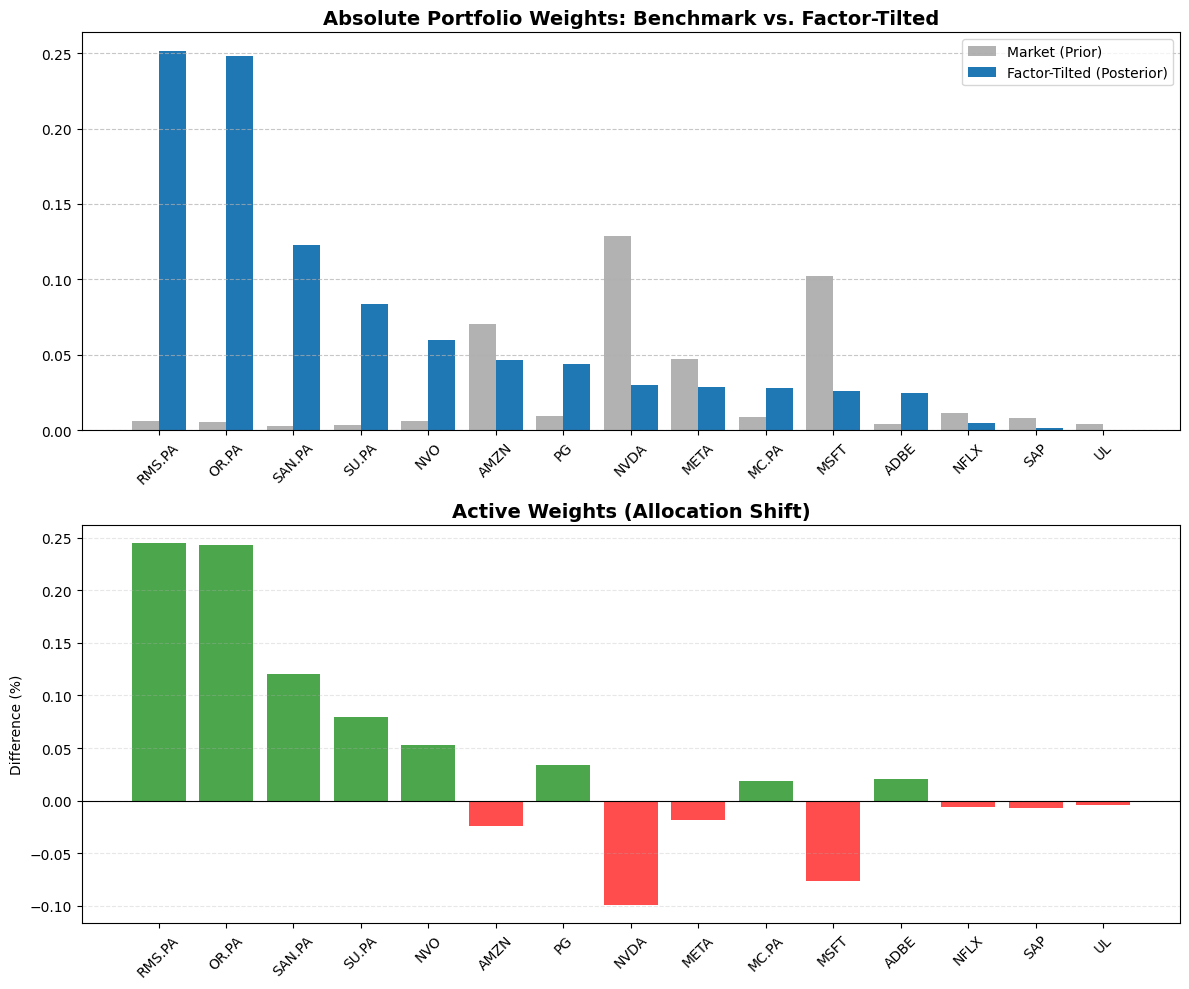

In [57]:
import matplotlib.pyplot as plt

# 1. Prepare the Data
benchmark_weights = (market_caps / market_caps.sum()).reindex(weights.index)
active_weights = weights - benchmark_weights

# Sort by weights to see the top holdings clearly
top_holdings = weights.sort_values(ascending=False).head(15)
names = top_holdings.index
idx = np.arange(len(names))

# 2. Create the Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1]})

# --- Top Plot: Absolute Weights ---
ax1.bar(idx - 0.2, benchmark_weights.loc[names], width=0.4, label='Market (Prior)', color='gray', alpha=0.6)
ax1.bar(idx + 0.2, weights.loc[names], width=0.4, label='Factor-Tilted (Posterior)', color='#1f77b4')
ax1.set_title("Absolute Portfolio Weights: Benchmark vs. Factor-Tilted", fontsize=14, fontweight='bold')
ax1.set_xticks(idx)
ax1.set_xticklabels(names, rotation=45)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Bottom Plot: Active Weights (The "Tilt") ---
# We use colors to distinguish between overweight and underweight
colors = ['green' if x > 0 else 'red' for x in active_weights.loc[names]]
ax2.bar(idx, active_weights.loc[names], color=colors, alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title("Active Weights (Allocation Shift)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Difference (%)")
ax2.set_xticks(idx)
ax2.set_xticklabels(names, rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

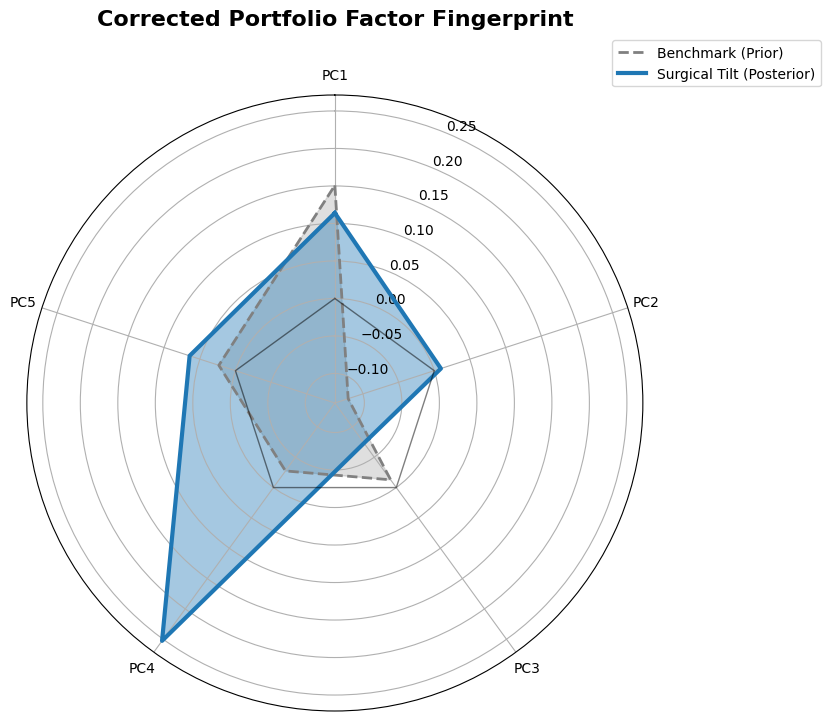

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Strict Alignment of Weights and Eigenvectors
# We reindex the loadings to match the weights' order precisely
aligned_loadings = macro_bl.loading.reindex(weights.index)

# 2. Compute the Betas (The 'Fingerprint')
# Dot product: (N_assets,) @ (N_assets, K_factors) -> (K_factors,)
benchmark_weights = (market_caps / market_caps.sum()).reindex(weights.index)
benchmark_betas = benchmark_weights.values @ aligned_loadings.values
optimal_betas = weights.values @ aligned_loadings.values

# 3. Radar Chart Construction
labels = [f"PC{i+1}" for i in range(len(benchmark_betas))]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

bench_plot = benchmark_betas.tolist() + [benchmark_betas[0]]
opt_plot = optimal_betas.tolist() + [optimal_betas[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw the Benchmark (The 'Prior' Shape)
ax.plot(angles, bench_plot, color='gray', linewidth=2, linestyle='--', label='Benchmark (Prior)')
ax.fill(angles, bench_plot, color='gray', alpha=0.25)

# Draw the Optimal Portfolio (The 'Surgical' Shape)
ax.plot(angles, opt_plot, color='#1f77b4', linewidth=3, label='Surgical Tilt (Posterior)')
ax.fill(angles, opt_plot, color='#1f77b4', alpha=0.4)

# Formatting for Clarity
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# Add a reference circle for 0.0 (The Neutrality Horizon)
ax.plot(angles, [0]*(num_vars+1), color='black', linewidth=1, alpha=0.5)

plt.title("Corrected Portfolio Factor Fingerprint", size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()